# 数据处理

## 1. 构建弱框标注

test visualization of annotation GT

In [1]:
from utils import parse_voc_xml, draw_boxes
from PIL import Image

class_map_encoding = {'leuko' : 0, 'eryth' : 1, 'mycete' : 2}
class_map_decoding = {v: k for k, v in class_map_encoding.items()}
xml_path = 'test_images/nh00001.xml'
image_path = 'test_images/nh00001.jpg'

image_info, boxes = parse_voc_xml(xml_path, class_map_encoding)
image = Image.open(image_path)
image = draw_boxes(image, boxes, class_map_decoding)
image.show()
for k, v in image_info.items():
    print(f'{k}: {v}')

width: 800
height: 600
depth: 3


build weak boxes from GT

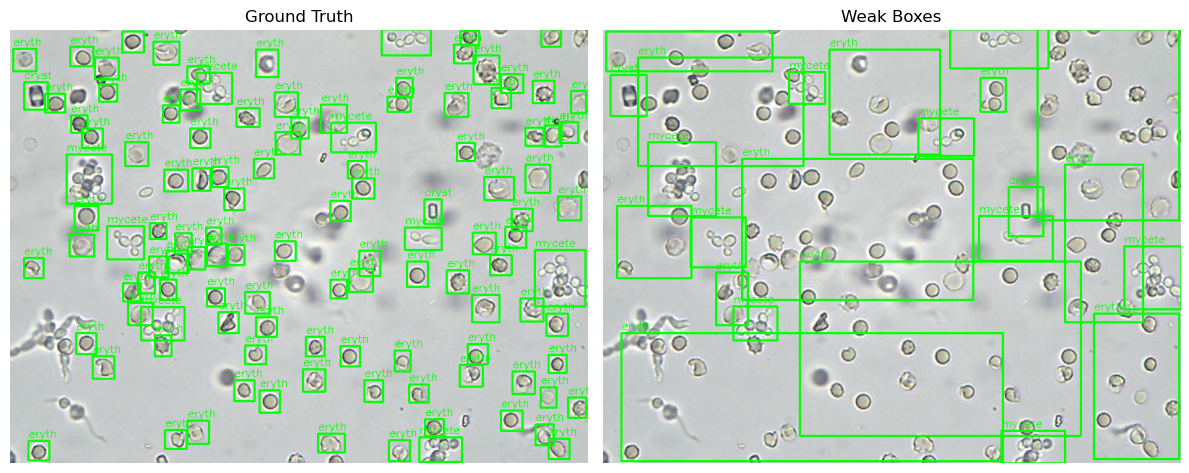

width: 800
height: 600
depth: 3


In [1]:
from utils import build_weak_boxes, parse_voc_xml, draw_boxes
from typing import List, Tuple
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

class_map_encoding = {'cast' : 0, 'cryst' : 1, 'epith' : 2, 'epithn' : 3, 'eryth' : 4, 'leuko' : 5, 'mycete' : 6}
class_map_decoding = {v: k for k, v in class_map_encoding.items()}
xml_path = 'test_images/nh01663.xml'
image_path = 'test_images/nh01663.jpg'

image = Image.open(image_path)
image_info, gt = parse_voc_xml(xml_path, class_map_encoding)
image_size = (image_info['width'], image_info['height'])
wb = build_weak_boxes(gt, purity_mode="center", image_size=image_size)
image_gt = draw_boxes(image, gt, class_map_decoding)
image_wb = draw_boxes(image, wb, class_map_decoding)

# Visualize GT and Weak Boxes side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Ground Truth visualization
axes[0].imshow(np.array(image_gt))
axes[0].set_title("Ground Truth")
axes[0].axis("off")

# Weak Boxes visualization
axes[1].imshow(np.array(image_wb))
axes[1].set_title("Weak Boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

for k, v in image_info.items():
    print(f'{k}: {v}')

## 2. 处理 Urinary Sediment Dataset

get all class names in the dataset

In [2]:
import xml.etree.ElementTree as ET
from pathlib import Path

def parse_voc_xml(xml_path: Path):
    """
    Parse a Pascal VOC style XML.
    Returns: (filename, objects)
      - filename: str or None
      - objects: list of dicts: {name, bbox(xmin,ymin,xmax,ymax)}
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        bnd = obj.find("bndbox")
        if bnd is None:
            # Some datasets may store other forms; skip if bbox missing
            continue
        def get_int(tag):
            v = bnd.findtext(tag)
            return int(float(v)) if v is not None else None

        xmin = get_int("xmin")
        ymin = get_int("ymin")
        xmax = get_int("xmax")
        ymax = get_int("ymax")

        if None in (xmin, ymin, xmax, ymax) or name is None:
            continue

        objects.append({
            "name": name.strip(),
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return filename, objects

In [3]:
import os

root_path = "./Origin_Dataset/Urinary Sediment Dataset/Annotations"
file_list = os.listdir(root_path)
xml_files = [os.path.join(root_path, f) for f in file_list if f.endswith('.xml')]

# Collect class names
class_set = set()
for xp in xml_files:
    filename, objs = parse_voc_xml(xp)
    for o in objs:
        class_set.add(o["name"])

classes = sorted(class_set)
for cls in classes:
    print(cls)

cast
cryst
epith
epithn
eryth
leuko
mycete


Transform GT to Weak Boxes and save to new XML files

- find the number of files with no weak boxes generated

In [1]:
from utils import build_weak_boxes, parse_voc_xml, save_weak_boxes_as_voc_xml
import os

class_map_encoding = {'cast' : 0, 'cryst' : 1, 'epith' : 2, 'epithn' : 3, 'eryth' : 4, 'leuko' : 5, 'mycete' : 6}
load_root_path = "./data/raw/Urinary Sediment Dataset/Annotations"
save_root_path = "./data/processed/Urinary Sediment Dataset/Annotations"

load_xml_files = os.listdir(load_root_path)
cnt = 0
files_causing_no_weak_boxes = []
for f in load_xml_files:
    load_xml_path = os.path.join(load_root_path, f)
    image_info, gt = parse_voc_xml(load_xml_path, class_map_encoding)
    image_size = (image_info['width'], image_info['height'])
    weak_boxes = build_weak_boxes(gt, purity_mode="center", image_size=image_size)
    if len(weak_boxes) == 0:
        cnt += 1
        files_causing_no_weak_boxes.append(f)
        print(f'No weak boxes generated for {f}, skipping saving.')
        continue
print(f'Total files with no weak boxes: {cnt}')

No weak boxes generated for nh00743.xml, skipping saving.
No weak boxes generated for nh01663.xml, skipping saving.
No weak boxes generated for nh01665.xml, skipping saving.
No weak boxes generated for nh01702.xml, skipping saving.
No weak boxes generated for nh01703.xml, skipping saving.
No weak boxes generated for nh01721.xml, skipping saving.
No weak boxes generated for nh01729.xml, skipping saving.
No weak boxes generated for nh01818.xml, skipping saving.
No weak boxes generated for nh01886.xml, skipping saving.
No weak boxes generated for nh01986.xml, skipping saving.
No weak boxes generated for nh02095.xml, skipping saving.
No weak boxes generated for nh02329.xml, skipping saving.
No weak boxes generated for nh02457.xml, skipping saving.
No weak boxes generated for nh02463.xml, skipping saving.
No weak boxes generated for nh03265.xml, skipping saving.
No weak boxes generated for nh03268.xml, skipping saving.
No weak boxes generated for nh03269.xml, skipping saving.
No weak boxes 

- save all weak boxes XML files

In [2]:
from utils import build_weak_boxes, parse_voc_xml, save_weak_boxes_as_voc_xml
import os

class_map_encoding = {'cast' : 0, 'cryst' : 1, 'epith' : 2, 'epithn' : 3, 'eryth' : 4, 'leuko' : 5, 'mycete' : 6}
class_map_decoding = {v: k for k, v in class_map_encoding.items()}
load_root_path = "./data/raw/Urinary Sediment Dataset/Annotations"
save_root_path = "./data/processed/Urinary Sediment Dataset/Annotations"

load_xml_files = os.listdir(load_root_path)
for f in load_xml_files:
    if f in files_causing_no_weak_boxes:
        continue
    load_xml_path = os.path.join(load_root_path, f)
    image_info, gt = parse_voc_xml(load_xml_path, class_map_encoding)
    image_size = (image_info['width'], image_info['height'])
    weak_boxes = build_weak_boxes(gt, purity_mode="center", image_size=image_size)
    save_xml_path = os.path.join(save_root_path, f)
    filename = f.split('.xml')[0]
    save_weak_boxes_as_voc_xml(save_xml_path, image_info, weak_boxes, class_map_decoding, filename=filename, folder='Cells', database='The Cells Database')